# StarGAN 실습 — 하나의 G로 여러 얼굴 속성 바꾸기

> **StarGAN: Unified GANs for Multi-Domain Image-to-Image Translation** (Choi et al., CVPR 2018)

이 노트북은 **소형 StarGAN을 직접 구현하고 짧게 학습**하면서 핵심 아이디어를 체감하는 게 목표입니다 (GPU 기준 약 15~20분).

논문의 핵심 3가지를 코드로 확인합니다:
1. **Label conditioning** — Generator에 이미지 `x`와 target label `c`를 함께 넣어 `G(x, c)` 로 원하는 도메인을 지정
2. **D_src / D_cls 분리** — Discriminator가 real/fake 판별과 domain 분류를 동시에 수행
3. **Reconstruction loss** — `G(G(x,c), c')` 로 원본 복원 → identity·content 보존

> ⚠️ **먼저 GPU를 켜세요:** 상단 메뉴 `런타임 → 런타임 유형 변경 → 하드웨어 가속기: T4 GPU`


## 1. 환경 설정

PyTorch는 Colab에 기본 설치되어 있습니다. GPU가 잡혔는지 확인합니다.

In [1]:
import torch, torchvision, random, os, time
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('PyTorch:', torch.__version__)
print('Device :', device)
if device == 'cpu':
    print('⚠️ GPU가 꺼져 있습니다. [런타임 → 런타임 유형 변경 → T4 GPU] 후 다시 실행하세요. (CPU로도 동작은 하지만 매우 느립니다)')

PyTorch: 2.11.0+cu128
Device : cuda


## 2. 데이터 준비 (CelebA)

CelebA 전체(20만 장)는 너무 크므로, **소량만 내려받아** 빠르게 학습합니다.

다룰 속성은 5개입니다:
`Black_Hair`, `Blond_Hair`, `Brown_Hair` (머리색 3종, 상호배타) + `Male` (성별) + `Young` (나이)

> 데이터 다운로드가 환경에 따라 막힐 수 있어, 실패하면 **자동으로 합성(synthetic) 데이터로 폴백**합니다. 합성 데이터로도 코드 흐름과 학습 동작을 모두 확인할 수 있습니다.

In [2]:
# CelebA 일부를 Hugging Face 미러에서 내려받기 시도
N_IMAGES = 2000          # 사용할 이미지 수 (속도 위해 소량)
IMG_SIZE = 64            # 이미지 해상도 (64x64로 축소 → 빠름)
SELECTED = ['Black_Hair', 'Blond_Hair', 'Brown_Hair', 'Male', 'Young']
C_DIM = len(SELECTED)

USE_SYNTHETIC = False
images, labels = None, None

try:
    from datasets import load_dataset
except Exception:
    !pip install -q datasets
    from datasets import load_dataset

from torchvision import transforms
tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),   # [-1, 1] 범위
])

def to_binary(v):
    # 속성값이 bool / 0~1 / -1~1 어떤 형태든 1(있음)을 1.0으로
    try: v = int(v)
    except Exception: v = 1 if bool(v) else -1
    return 1.0 if v == 1 else 0.0

# 여러 미러를 순서대로 시도 (앞쪽이 실패하면 다음으로)
CANDIDATES = ['tpremoli/CelebA-attrs', 'flwrlabs/celeba']
for repo in CANDIDATES:
    try:
        print(f'시도: {repo} (1~2분 소요) ...')
        ds = load_dataset(repo, split=f'train[:{N_IMAGES}]')
        cols = ds.column_names
        if not all(s in cols for s in SELECTED):
            print(f'  → 속성 컬럼이 없어 건너뜀 (cols 예시: {cols[:6]})'); continue
        imgs, labs = [], []
        for ex in ds:
            imgs.append(tf(ex['image'].convert('RGB')))
            labs.append([to_binary(ex[s]) for s in SELECTED])
        images = torch.stack(imgs)
        labels = torch.tensor(labs, dtype=torch.float32)
        print('✅ CelebA 로드 완료:', repo, images.shape, labels.shape); break
    except Exception as e:
        print('  → 실패:', str(e)[:150])

if images is None:
    print('⚠️ 모든 미러 실패 → 합성 데이터로 폴백합니다. (코드 흐름·학습 동작은 동일하게 확인 가능)')
    USE_SYNTHETIC = True
    N = N_IMAGES
    images = torch.rand(N, 3, IMG_SIZE, IMG_SIZE)
    labels = (torch.rand(N, C_DIM) > 0.5).float()
    hair = torch.zeros(N, 3)
    hair[torch.arange(N), torch.randint(0, 3, (N,))] = 1.0   # 머리색 one-hot
    labels[:, :3] = hair
    for i in range(N):                              # label이 픽셀에 반영되게
        ch = int(labels[i, :3].argmax())
        images[i, ch] = images[i, ch] * 0.4 + 0.6
        if labels[i, 3] > 0: images[i] = images[i] * 0.7      # Male → 어둡게
        if labels[i, 4] > 0: images[i] = images[i] * 0.5 + 0.5 # Young → 밝게
    images = (images - 0.5) / 0.5

# DataLoader
from torch.utils.data import TensorDataset, DataLoader
BATCH = 16
loader = DataLoader(TensorDataset(images, labels), batch_size=BATCH, shuffle=True, drop_last=True)
print(f'배치 크기 {BATCH}, 총 {len(loader)} 배치  |  합성여부={USE_SYNTHETIC}')

시도: tpremoli/CelebA-attrs (1~2분 소요) ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/2.74k [00:00<?, ?B/s]

data/train-00000-of-00003.parquet:   0%|          | 0.00/381M [00:00<?, ?B/s]

data/train-00001-of-00003.parquet:   0%|          | 0.00/381M [00:00<?, ?B/s]

...

data/test-00000-of-00001.parquet:   0%|          | 0.00/141M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/162770 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/19962 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/19867 [00:00<?, ? examples/s]

✅ CelebA 로드 완료: tpremoli/CelebA-attrs torch.Size([2000, 3, 64, 64]) torch.Size([2000, 5])
배치 크기 16, 총 125 배치  |  합성여부=False


### 데이터 미리보기
학습 전 원본 이미지 몇 장과 그 속성 라벨을 확인합니다.

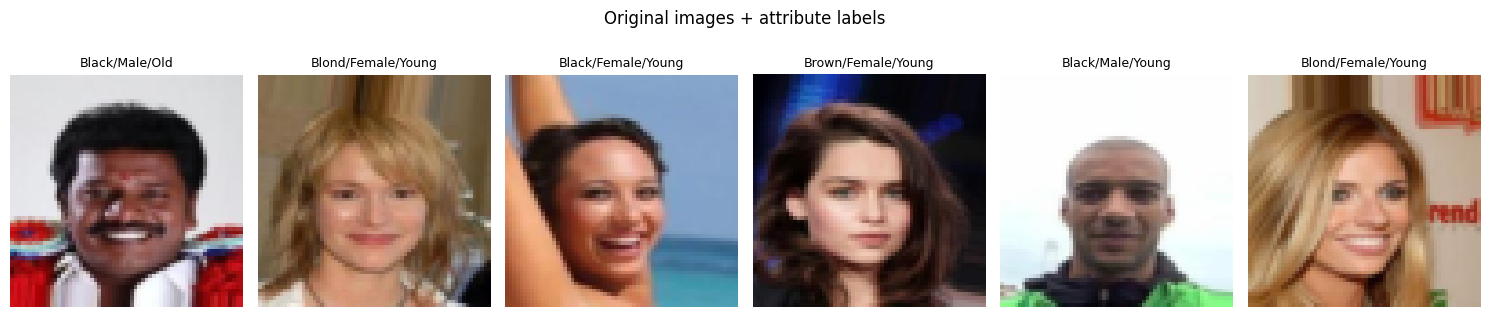

In [3]:
def denorm(x):
    return (x * 0.5 + 0.5).clamp(0, 1)

def label_to_text(lab):
    hair = ['Black','Blond','Brown'][int(lab[:3].argmax())]
    sex  = 'Male' if lab[3] > 0.5 else 'Female'
    age  = 'Young' if lab[4] > 0.5 else 'Old'
    return f'{hair}/{sex}/{age}'

xb, yb = next(iter(loader))
fig, axes = plt.subplots(1, 6, figsize=(15, 3))
for i, ax in enumerate(axes):
    ax.imshow(denorm(xb[i]).permute(1, 2, 0).numpy())
    ax.set_title(label_to_text(yb[i]), fontsize=9)
    ax.axis('off')
plt.suptitle('Original images + attribute labels', y=1.05); plt.tight_layout(); plt.show()

## 3. Generator 구현

StarGAN의 Generator는 **이미지 `x` 와 target label `c` 를 함께** 입력받습니다.

핵심 트릭: label `c`(길이 5 벡터)를 **이미지와 같은 H×W 로 펼쳐서(spatial replication)** 채널 방향으로 이어 붙입니다.
→ 입력 채널 = `3(RGB) + 5(label)` = 8

구조는 CycleGAN과 유사: `down-sampling → residual blocks → up-sampling`.

In [4]:
class ResidualBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(dim, dim, 3, 1, 1, bias=False),
            nn.InstanceNorm2d(dim, affine=True), nn.ReLU(inplace=True),
            nn.Conv2d(dim, dim, 3, 1, 1, bias=False),
            nn.InstanceNorm2d(dim, affine=True),
        )
    def forward(self, x):
        return x + self.block(x)     # skip connection

class Generator(nn.Module):
    def __init__(self, conv_dim=32, c_dim=5, n_res=3):
        super().__init__()
        layers = [nn.Conv2d(3 + c_dim, conv_dim, 7, 1, 3, bias=False),
                  nn.InstanceNorm2d(conv_dim, affine=True), nn.ReLU(inplace=True)]
        d = conv_dim
        for _ in range(2):                       # down x2
            layers += [nn.Conv2d(d, d*2, 4, 2, 1, bias=False),
                       nn.InstanceNorm2d(d*2, affine=True), nn.ReLU(inplace=True)]
            d *= 2
        for _ in range(n_res):                   # residual blocks
            layers += [ResidualBlock(d)]
        for _ in range(2):                       # up x2
            layers += [nn.ConvTranspose2d(d, d//2, 4, 2, 1, bias=False),
                       nn.InstanceNorm2d(d//2, affine=True), nn.ReLU(inplace=True)]
            d //= 2
        layers += [nn.Conv2d(d, 3, 7, 1, 3, bias=False), nn.Tanh()]
        self.main = nn.Sequential(*layers)

    def forward(self, x, c):
        # label c 를 (B, c_dim, H, W) 로 펼쳐 이미지에 concat
        c = c.view(c.size(0), c.size(1), 1, 1).repeat(1, 1, x.size(2), x.size(3))
        x = torch.cat([x, c], dim=1)
        return self.main(x)

G = Generator(conv_dim=32, c_dim=C_DIM, n_res=3).to(device)
print(f'Generator 파라미터: {sum(p.numel() for p in G.parameters())/1e6:.2f}M')

Generator 파라미터: 1.23M


## 4. Discriminator 구현

StarGAN의 Discriminator는 **두 개의 출력**을 가집니다 (논문의 핵심):

- **`D_src`** : 이미지가 real인지 fake인지 (PatchGAN 형태)
- **`D_cls`** : 이미지가 **어떤 domain(속성)** 에 속하는지 분류

이 `D_cls` 덕분에 Generator가 단순히 진짜 같은 이미지가 아니라 **target label에 맞는** 이미지를 만들도록 유도됩니다.

In [5]:
class Discriminator(nn.Module):
    def __init__(self, image_size=64, conv_dim=32, c_dim=5, n_layers=5):
        super().__init__()
        layers = [nn.Conv2d(3, conv_dim, 4, 2, 1), nn.LeakyReLU(0.01)]
        d = conv_dim
        for _ in range(1, n_layers):
            layers += [nn.Conv2d(d, d*2, 4, 2, 1), nn.LeakyReLU(0.01)]
            d *= 2
        self.main = nn.Sequential(*layers)
        ksize = image_size // (2 ** n_layers)
        self.conv_src = nn.Conv2d(d, 1, 3, 1, 1, bias=False)        # real/fake
        self.conv_cls = nn.Conv2d(d, c_dim, ksize, bias=False)     # domain 분류

    def forward(self, x):
        h = self.main(x)
        out_src = self.conv_src(h)
        out_cls = self.conv_cls(h).view(x.size(0), -1)
        return out_src, out_cls

D = Discriminator(image_size=IMG_SIZE, conv_dim=32, c_dim=C_DIM, n_layers=5).to(device)
print(f'Discriminator 파라미터: {sum(p.numel() for p in D.parameters())/1e6:.2f}M')

Discriminator 파라미터: 2.80M


## 5. 손실 함수와 학습 루프

세 가지 loss를 결합합니다 (논문 Eq. 5, 6):

| Loss | 역할 |
|---|---|
| **Adversarial** (+ WGAN-GP) | 생성 이미지가 진짜처럼 보이게 |
| **Domain classification** | target domain으로 분류되게 |
| **Reconstruction** (L1) | 원본 content·identity 보존 |

`λ_cls = 1`, `λ_rec = 10` (논문 설정). 학습 안정화를 위해 WGAN-GP의 gradient penalty를 사용합니다.

In [6]:
def gradient_penalty(D, real, fake):
    alpha = torch.rand(real.size(0), 1, 1, 1, device=real.device)
    x = (alpha * real + (1 - alpha) * fake).requires_grad_(True)
    out, _ = D(x)
    grad = torch.autograd.grad(out, x, grad_outputs=torch.ones_like(out),
                               create_graph=True, retain_graph=True)[0]
    grad = grad.view(grad.size(0), -1)
    return ((grad.norm(2, dim=1) - 1) ** 2).mean()

def rand_target_labels(batch_labels):
    # 머리색은 one-hot(상호배타)으로 무작위, 성별/나이는 베르누이로 무작위
    n = batch_labels.size(0)
    trg = batch_labels.clone()
    hair = torch.zeros(n, 3)
    hair[torch.arange(n), torch.randint(0, 3, (n,))] = 1.0
    trg[:, :3] = hair
    trg[:, 3] = (torch.rand(n) > 0.5).float()
    trg[:, 4] = (torch.rand(n) > 0.5).float()
    return trg

g_opt = torch.optim.Adam(G.parameters(), 1e-4, betas=(0.5, 0.999))
d_opt = torch.optim.Adam(D.parameters(), 1e-4, betas=(0.5, 0.999))
bce = nn.BCEWithLogitsLoss()

LAMBDA_CLS, LAMBDA_REC, LAMBDA_GP = 1.0, 10.0, 10.0
N_CRITIC = 5     # D를 5번 업데이트할 때 G를 1번 (WGAN 관례)
print('손실 함수 및 옵티마이저 준비 완료')

손실 함수 및 옵티마이저 준비 완료


### 학습 실행

아래 셀이 실제 학습입니다. `EPOCHS` 를 늘리면 품질이 좋아지지만 시간이 더 걸립니다.
**T4 GPU 기준 5 epoch에 약 5~10분**입니다. 진행 로그로 loss 추이를 확인하세요.

In [7]:
EPOCHS = 5        # 시간이 남으면 8~10으로 늘려보세요

G.train(); D.train()
hist = {'d': [], 'g': [], 'rec': [], 'cls': []}
start = time.time()
step = 0

for epoch in range(EPOCHS):
    for x_real, label_org in loader:
        x_real = x_real.to(device)
        label_org = label_org.to(device)
        label_trg = rand_target_labels(label_org.cpu()).to(device)

        # ===== (1) Discriminator =====
        out_src, out_cls = D(x_real)
        d_loss_real = -out_src.mean()
        d_loss_cls = bce(out_cls, label_org)

        x_fake = G(x_real, label_trg)
        out_src_f, _ = D(x_fake.detach())
        d_loss_fake = out_src_f.mean()

        gp = gradient_penalty(D, x_real, x_fake.detach())
        d_loss = d_loss_real + d_loss_fake + LAMBDA_CLS*d_loss_cls + LAMBDA_GP*gp
        d_opt.zero_grad(); d_loss.backward(); d_opt.step()

        # ===== (2) Generator (N_CRITIC 마다 1번) =====
        if step % N_CRITIC == 0:
            x_fake = G(x_real, label_trg)
            out_src_f, out_cls_f = D(x_fake)
            g_loss_fake = -out_src_f.mean()
            g_loss_cls = bce(out_cls_f, label_trg)

            x_rec = G(x_fake, label_org)                 # 다시 원래 label로 복원
            g_loss_rec = torch.mean(torch.abs(x_real - x_rec))

            g_loss = g_loss_fake + LAMBDA_CLS*g_loss_cls + LAMBDA_REC*g_loss_rec
            g_opt.zero_grad(); g_loss.backward(); g_opt.step()

            hist['d'].append(d_loss.item()); hist['g'].append(g_loss.item())
            hist['rec'].append(g_loss_rec.item()); hist['cls'].append(g_loss_cls.item())
        step += 1

    print(f'[Epoch {epoch+1}/{EPOCHS}] '
          f'D={d_loss.item():6.3f}  G={g_loss.item():6.3f}  '
          f'rec={g_loss_rec.item():.3f}  cls={g_loss_cls.item():.3f}  '
          f'({time.time()-start:.0f}s)')

print(f'\n✅ 학습 완료! 총 {time.time()-start:.0f}초')

[Epoch 1/5] D=-0.679  G= 3.109  rec=0.360  cls=0.730  (6s)
[Epoch 2/5] D=-0.376  G= 2.365  rec=0.338  cls=0.707  (9s)
[Epoch 3/5] D=-1.136  G= 1.176  rec=0.324  cls=0.676  (13s)
[Epoch 4/5] D=-3.445  G= 6.159  rec=0.296  cls=0.894  (17s)
[Epoch 5/5] D=-0.999  G= 4.072  rec=0.311  cls=0.816  (21s)

✅ 학습 완료! 총 21초


### 학습 곡선
Reconstruction loss가 내려가면 G가 원본을 잘 보존하고 있다는 신호입니다.

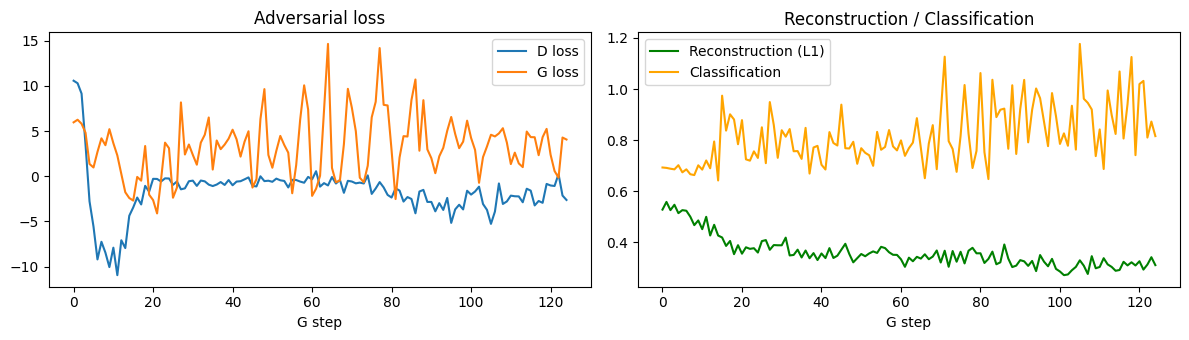

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
ax[0].plot(hist['d'], label='D loss'); ax[0].plot(hist['g'], label='G loss')
ax[0].set_title('Adversarial loss'); ax[0].legend(); ax[0].set_xlabel('G step')
ax[1].plot(hist['rec'], label='Reconstruction (L1)', color='green')
ax[1].plot(hist['cls'], label='Classification', color='orange')
ax[1].set_title('Reconstruction / Classification'); ax[1].legend(); ax[1].set_xlabel('G step')
plt.tight_layout(); plt.show()

## 6. 결과 확인 — 같은 얼굴, 다른 속성

이제 핵심을 봅니다. **하나의 입력 이미지**에 대해 **target label만 바꿔가며** Generator를 돌립니다.
같은 G가 label에 따라 다른 변환을 수행하는지 확인하세요.

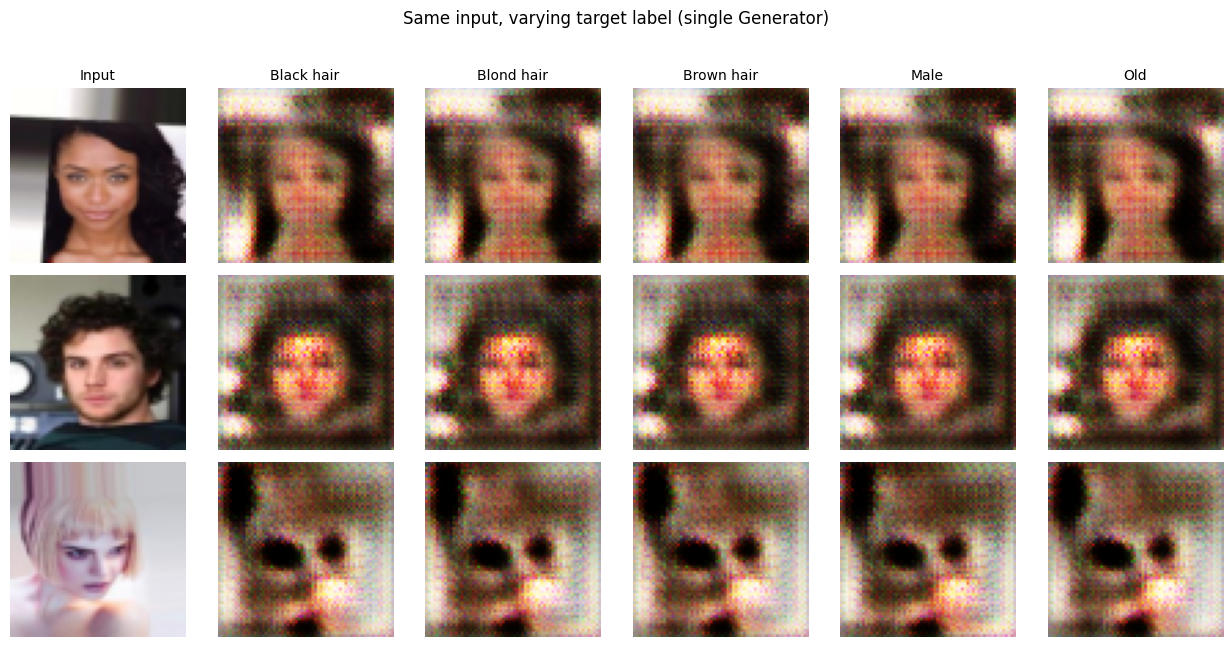

In [9]:
G.eval()

# 변환해 볼 target label 목록 (머리색 one-hot + 성별/나이)
def make_label(black=0, blond=0, brown=0, male=0, young=1):
    return torch.tensor([[black, blond, brown, male, young]], dtype=torch.float32)

targets = [
    ('Black hair',  make_label(black=1, young=1)),
    ('Blond hair',  make_label(blond=1, young=1)),
    ('Brown hair',  make_label(brown=1, young=1)),
    ('Male',        make_label(black=1, male=1, young=1)),
    ('Old',         make_label(black=1, young=0)),
]

# 입력 이미지 3장 선택
xb, yb = next(iter(loader))
n_show = 3
fig, axes = plt.subplots(n_show, len(targets)+1, figsize=(2.1*(len(targets)+1), 2.1*n_show))
with torch.no_grad():
    for r in range(n_show):
        x = xb[r:r+1].to(device)
        axes[r, 0].imshow(denorm(x[0].cpu()).permute(1,2,0).numpy())
        axes[r, 0].set_title('Input' if r==0 else '', fontsize=10)
        axes[r, 0].axis('off')
        for j, (name, lab) in enumerate(targets):
            out = G(x, lab.to(device))
            axes[r, j+1].imshow(denorm(out[0].cpu()).permute(1,2,0).numpy())
            axes[r, j+1].set_title(name if r==0 else '', fontsize=10)
            axes[r, j+1].axis('off')
plt.suptitle('Same input, varying target label (single Generator)', y=1.02)
plt.tight_layout(); plt.show()

> 💡 **관찰 포인트**
> - 5 epoch 정도의 짧은 학습이라 결과는 거칠지만, **label에 따라 출력이 달라지는 경향**이 보이면 성공입니다.
> - 머리색 칸끼리 비교하면 색조 변화가, Male/Old 칸에서는 톤 변화가 나타납니다.
> - 품질을 높이려면: `EPOCHS` 증가, `IMG_SIZE`/`conv_dim` 증가, `N_IMAGES` 증가 → 단, 시간이 늘어납니다.
> - (합성 데이터로 폴백된 경우) 실제 얼굴은 아니지만 "label → 출력 변화" 메커니즘은 동일하게 확인됩니다.

## 7. Reconstruction 확인 — 원본이 보존되는가?

`x → G(x, c_trg) → G(·, c_org)` 로 다시 원래 속성으로 되돌렸을 때 원본과 비슷해야 합니다.
이것이 **content·identity 보존**의 핵심 장치입니다.

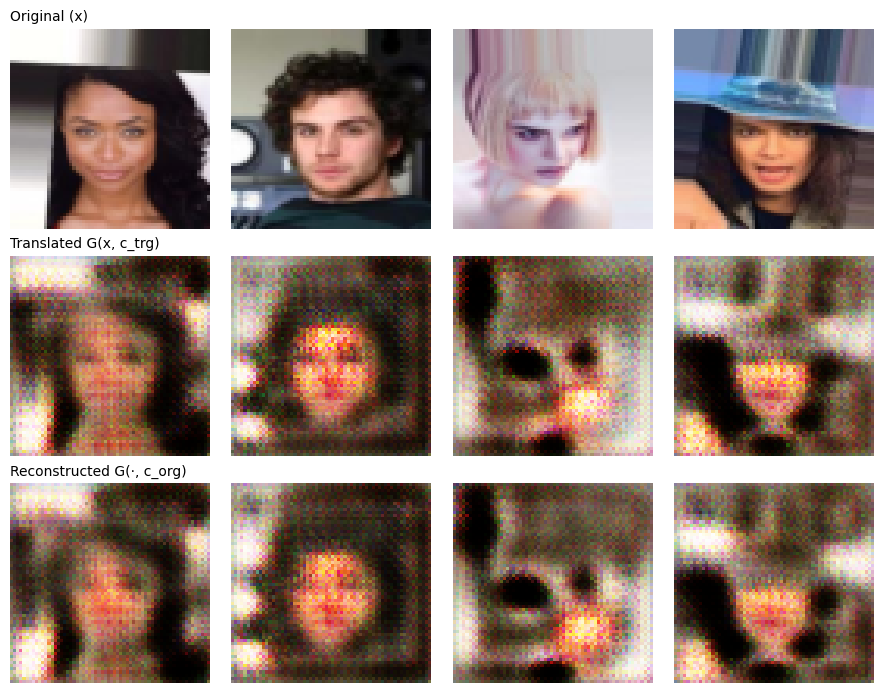

원본 vs 복원 평균 L1 거리: 0.3949  (작을수록 잘 보존된 것)


In [10]:
with torch.no_grad():
    x = xb[:4].to(device)
    org = yb[:4].to(device)
    trg = rand_target_labels(yb[:4]).to(device)
    fake = G(x, trg)
    rec  = G(fake, org)

fig, axes = plt.subplots(3, 4, figsize=(9, 7))
rows = [('Original (x)', x), ('Translated G(x, c_trg)', fake), ('Reconstructed G(·, c_org)', rec)]
for i, (title, imgs) in enumerate(rows):
    for j in range(4):
        axes[i, j].imshow(denorm(imgs[j].cpu()).permute(1,2,0).numpy())
        axes[i, j].axis('off')
        if j == 0: axes[i, j].set_ylabel(title, fontsize=10)
    axes[i, 0].set_title(title, fontsize=10, loc='left')
plt.tight_layout(); plt.show()

l1 = torch.mean(torch.abs(x - rec)).item()
print(f'원본 vs 복원 평균 L1 거리: {l1:.4f}  (작을수록 잘 보존된 것)')

## 8. 정리 & 토의

이번 실습에서 코드로 확인한 것:
1. **Label conditioning** — label을 spatial하게 펼쳐 이미지에 concat → 단일 G가 여러 변환 수행
2. **D_cls** — Discriminator의 분류 헤드가 G를 target domain 쪽으로 유도
3. **Reconstruction loss** — 같은 G를 두 번 통과시켜 content 보존

**더 생각해볼 질문**
- 짧은 학습에서 머리색보다 성별/나이 변환이 더 어려운 이유는? (attribute가 차지하는 픽셀 영역·전역성과 관련)
- `λ_rec` 를 키우면 원본은 잘 보존되지만 변환 강도는 약해질 수 있다. 이 trade-off를 어떻게 조절할까?
- 같은 (x, c)에 대해 항상 같은 결과만 나온다. 다양한 출력을 원한다면? (→ StarGAN v2의 style code 도입 배경)

**시간이 남으면 실험해보기**
- `EPOCHS` 를 10으로 늘려 품질 변화 관찰
- `LAMBDA_REC` 를 5 또는 20으로 바꿔 변환 강도 vs 보존 trade-off 확인
- `IMG_SIZE` 를 128로 (단, 학습 시간 크게 증가)
